# End-to-End Analysis: Financial Sample Dataset
Sales, Discounts & Profitability — full reproducible pipeline

**Steps:** clean & validate → SQL analysis → Pandas analysis → visualization → findings

Dataset: Financial Sample (Microsoft), 700 orders, 16 fields, 5 countries, 5 segments, 6 products, Sep 2013–Dec 2014.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.width', 120)
%matplotlib inline

## 1. Data Cleaning & Validation

In [2]:
RAW_PATH = "data/Sample_data.xlsx"

df = pd.read_excel(RAW_PATH)
df.columns = [c.strip() for c in df.columns]
print("Raw shape:", df.shape)
df.head()

Raw shape: (700, 16)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Duplicate rows: 0

Missing values per column:
Discount Band    53
dtype: int64


In [4]:
missing_band = df["Discount Band"].isna()
all_zero_discount = (df.loc[missing_band, "Discounts"] == 0).all()
print(f"Blank Discount Band rows: {missing_band.sum()}")
print(f"All of them have Discounts == 0: {all_zero_discount}")

df.loc[missing_band, "Discount Band"] = "None"


Blank Discount Band rows: 53
All of them have Discounts == 0: True


In [5]:
# Cross-check calculated fields against their formulas
gross_mismatch = (df["Units Sold"] * df["Sale Price"] - df["Gross Sales"]).abs() > 0.01
sales_mismatch  = (df["Gross Sales"] - df["Discounts"] - df["Sales"]).abs() > 0.01
profit_mismatch = (df["Sales"] - df["COGS"] - df["Profit"]).abs() > 0.01

print("Gross Sales mismatches:", gross_mismatch.sum())
print("Sales mismatches:", sales_mismatch.sum())
print("Profit mismatches:", profit_mismatch.sum())

Gross Sales mismatches: 0
Sales mismatches: 0
Profit mismatches: 0


In [6]:
BAND_ORDER = ["None", "Low", "Medium", "High"]
df["Discount Band"] = pd.Categorical(df["Discount Band"], categories=BAND_ORDER, ordered=True)
df["Date"] = pd.to_datetime(df["Date"])

df.to_csv("data/cleaned_financial_data.csv", index=False)
print("Cleaned dataset saved -> shape", df.shape)

Cleaned dataset saved -> shape (700, 16)


## 2. SQL Analysis (SQLite)
Load the cleaned data into SQLite and answer the business questions with SQL.

In [7]:
conn = sqlite3.connect("data/financial_data.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

q_segment = '''
    SELECT Segment,
           ROUND(SUM(Sales), 2)  AS Sales,
           ROUND(SUM(Profit), 2) AS Profit,
           ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS Margin_Pct
    FROM sales
    GROUP BY Segment
    ORDER BY Profit DESC;
'''
segment_profit = pd.read_sql_query(q_segment, conn)
segment_profit

,Segment,Sales,Profit,Margin_Pct
0,Government,52504260.67,11388173.17,21.69
1,Small Business,42427918.50,4143168.50,9.77
2,Channel Partners,1800593.64,1316803.14,73.13
3,Midmarket,2381883.08,660103.07,27.71
4,Enterprise,19611694.38,-614545.63,-3.13


In [8]:
q_band = '''
    SELECT "Discount Band" AS Discount_Band,
           ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS Margin_Pct
    FROM sales
    GROUP BY "Discount Band"
    ORDER BY CASE "Discount Band"
                WHEN 'None' THEN 1 WHEN 'Low' THEN 2
                WHEN 'Medium' THEN 3 WHEN 'High' THEN 4 END;
'''
margin_by_band = pd.read_sql_query(q_band, conn)
margin_by_band

,Discount_Band,Margin_Pct
0,None,21.86
1,Low,17.87
2,Medium,14.39
3,High,9.07


In [9]:
q_segment_band = '''
    SELECT Segment, "Discount Band" AS Discount_Band,
           ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS Margin_Pct
    FROM sales
    GROUP BY Segment, "Discount Band"
    ORDER BY Segment;
'''
segment_band = pd.read_sql_query(q_segment_band, conn)
segment_band

,Segment,Discount_Band,Margin_Pct
0,Channel Partners,High,71.46
1,Channel Partners,Low,74.43
2,Channel Partners,Medium,73.12
3,Channel Partners,None,75.00
4,Enterprise,High,-9.53
5,Enterprise,Low,1.58
6,Enterprise,Medium,-3.03
7,Enterprise,None,4.00
8,Government,High,16.93
9,Government,Low,24.59


In [10]:
q_loss = '''
    SELECT "Discount Band" AS Discount_Band, COUNT(*) AS Loss_Orders
    FROM sales
    WHERE Segment = 'Enterprise' AND Profit < 0
    GROUP BY "Discount Band";
'''
pd.read_sql_query(q_loss, conn)

,Discount_Band,Loss_Orders
0,High,33
1,Medium,25


In [11]:
q_product = '''
    SELECT Product,
           ROUND(SUM(Sales), 2) AS Sales,
           ROUND(SUM(Profit), 2) AS Profit,
           ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS Margin_Pct
    FROM sales
    GROUP BY Product
    ORDER BY Sales DESC;
'''
product_perf = pd.read_sql_query(q_product, conn)
product_perf

,Product,Sales,Profit,Margin_Pct
0,Paseo,33011143.95,4797437.95,14.53
1,VTT,20511921.02,3034608.02,14.79
2,Velo,18250059.46,2305992.46,12.64
3,Amarilla,17747116.06,2814104.06,15.86
4,Montana,15390801.88,2114754.88,13.74
5,Carretera,13815307.88,1826804.89,13.22


In [12]:
q_country = '''
    SELECT Country,
           ROUND(SUM(Sales), 2) AS Sales,
           ROUND(100.0 * SUM(Profit) / SUM(Sales), 2) AS Margin_Pct
    FROM sales
    GROUP BY Country
    ORDER BY Sales DESC;
'''
country_perf = pd.read_sql_query(q_country, conn)
country_perf

,Country,Sales,Margin_Pct
0,United States of America,25029830.16,11.97
1,Canada,24887654.89,14.18
2,France,24354172.28,15.53
3,Germany,23505340.82,15.66
4,Mexico,20949352.11,13.88


In [13]:
q_monthly = '''
    SELECT strftime('%Y-%m', Date) AS Month,
           ROUND(SUM(Sales), 2) AS Sales,
           ROUND(SUM(Profit), 2) AS Profit
    FROM sales
    GROUP BY Month
    ORDER BY Month;
'''
monthly = pd.read_sql_query(q_monthly, conn)
monthly

,Month,Sales,Profit
0,2013-09,4484000.03,763603.03
1,2013-10,9295611.10,1657795.10
2,2013-11,7267203.30,765502.30
3,2013-12,5368441.08,691564.08
4,2014-01,6607761.68,814028.68
5,2014-02,7297531.39,1148547.39
6,2014-03,5586859.87,669866.87
7,2014-04,6964775.07,929984.57
8,2014-05,6210211.06,828640.06
9,2014-06,9518893.82,1473753.82


## 3. Visualizations (Matplotlib / Seaborn)

### Figure 1 — Total Profit by Segment
Government and Small Business drive most of the profit; Enterprise is the only segment in the red.

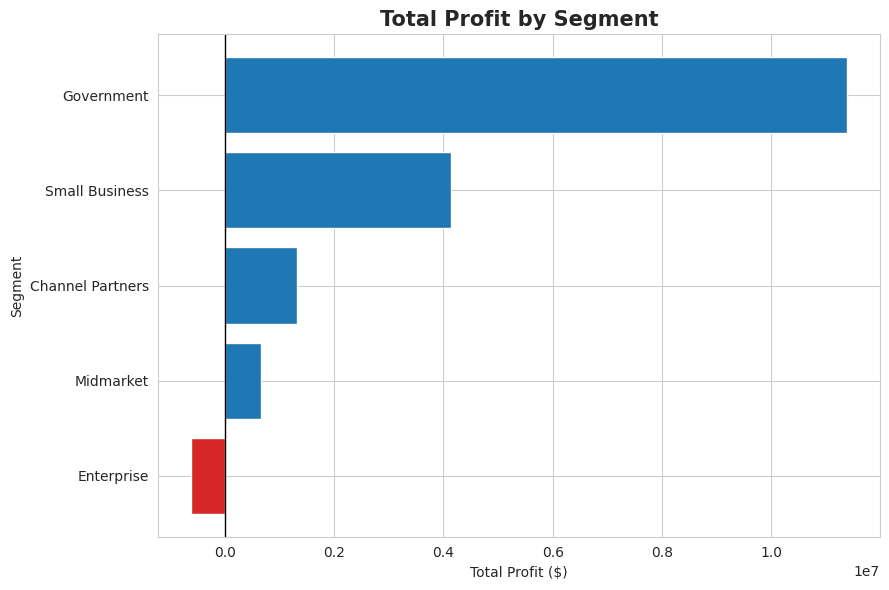

In [14]:
seg = df.groupby("Segment", observed=True)["Profit"].sum().sort_values(ascending=False)
colors = ["#d62728" if v < 0 else "#1f77b4" for v in seg.values]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(seg.index[::-1], seg.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Total Profit by Segment", fontsize=15, fontweight="bold")
ax.set_xlabel("Total Profit ($)")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.savefig("charts/01_profit_by_segment.png", dpi=150)
plt.show()

### Figure 2 — Profit Margin % by Discount Band
Margin erodes near-linearly as discount depth increases.

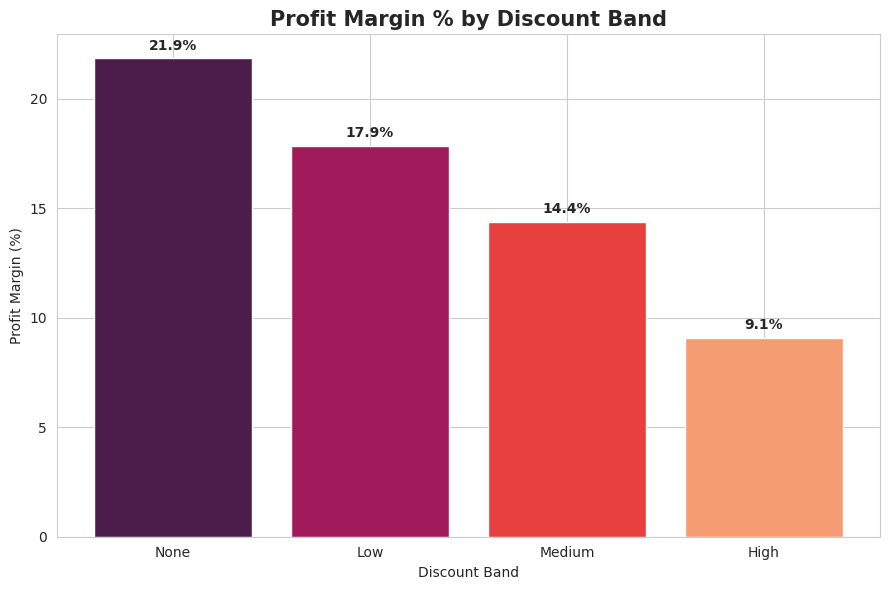

In [15]:
band = df.groupby("Discount Band", observed=True).apply(
    lambda g: 100 * g["Profit"].sum() / g["Sales"].sum()
).reindex(BAND_ORDER)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(band.index, band.values, color=sns.color_palette("rocket", len(band)))
for bar, val in zip(bars, band.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.4, f"{val:.1f}%", ha="center", fontweight="bold")
ax.set_title("Profit Margin % by Discount Band", fontsize=15, fontweight="bold")
ax.set_xlabel("Discount Band")
ax.set_ylabel("Profit Margin (%)")
plt.tight_layout()
plt.savefig("charts/02_margin_by_discount_band.png", dpi=150)
plt.show()

### Figure 3 — Profit Margin % Heatmap: Segment vs Discount Band
Pinpoints where the losses come from: Enterprise x Medium/High discount.

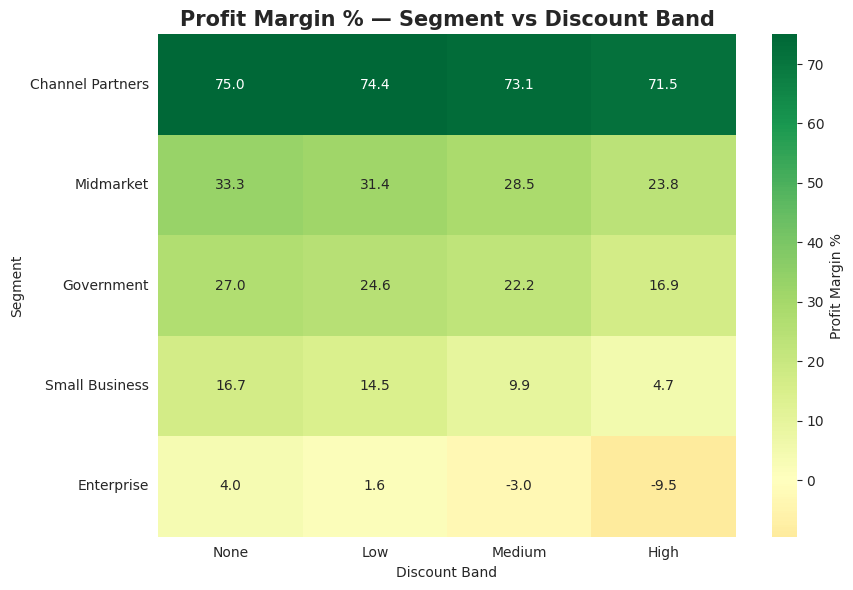

In [16]:
pivot = df.pivot_table(index="Segment", columns="Discount Band",
                        values=["Profit", "Sales"], aggfunc="sum", observed=True)
margin = 100 * pivot["Profit"] / pivot["Sales"]
margin = margin[BAND_ORDER]
margin = margin.reindex(margin.mean(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(margin, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "Profit Margin %"})
ax.set_title("Profit Margin % — Segment vs Discount Band", fontsize=15, fontweight="bold")
ax.set_xlabel("Discount Band")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.savefig("charts/03_heatmap_segment_discount.png", dpi=150)
plt.show()

### Figure 4 — Sales vs Profit by Product
Paseo is the revenue leader; Amarilla converts sales to profit most efficiently.

,Sales,Profit,Margin_Pct
Product,,,
Paseo,3.301114e+07,4797437.950,14.53
VTT,2.051192e+07,3034608.020,14.79
Velo,1.825006e+07,2305992.465,12.64
Amarilla,1.774712e+07,2814104.060,15.86
Montana,1.539080e+07,2114754.880,13.74
Carretera,1.381531e+07,1826804.885,13.22


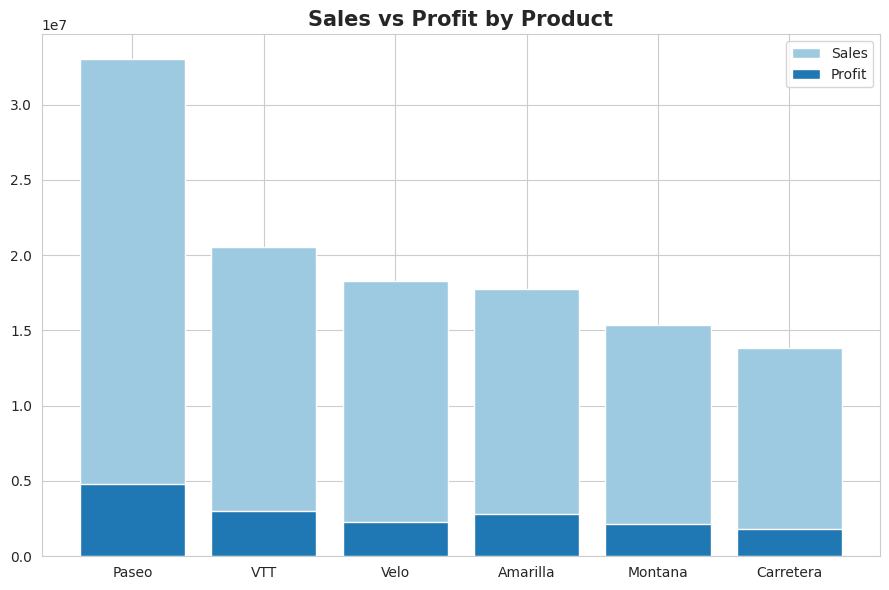

In [17]:
prod = df.groupby("Product")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(prod.index, prod["Sales"], label="Sales", color="#9ecae1")
ax.bar(prod.index, prod["Profit"], label="Profit", color="#1f77b4")
ax.set_title("Sales vs Profit by Product", fontsize=15, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("charts/04_sales_profit_by_product.png", dpi=150)
plt.show()

prod["Margin_Pct"] = (100 * prod["Profit"] / prod["Sales"]).round(2)
prod

### Figure 5 — Total Sales by Country (label = Profit Margin %)
All five countries are solidly profitable; the US has the largest base but thinnest margin.

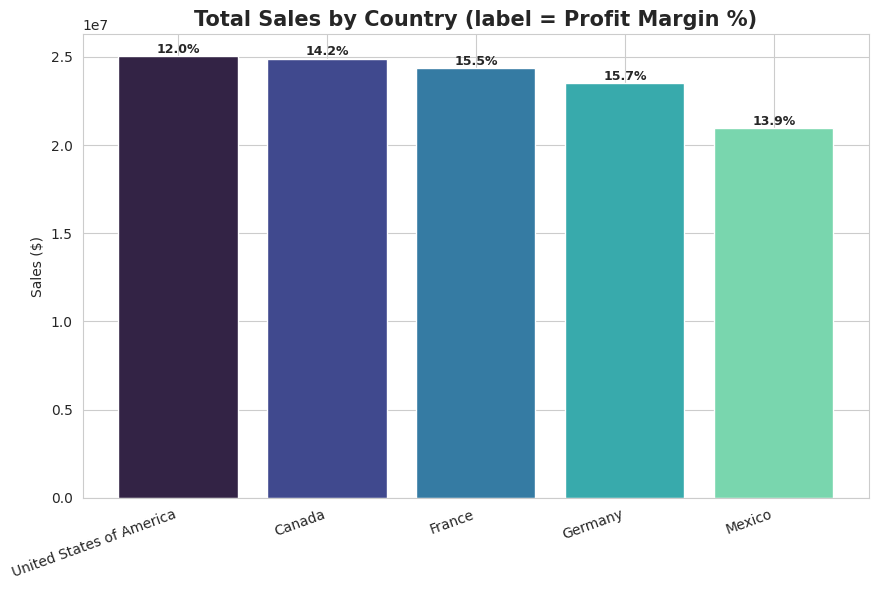

In [18]:
country = df.groupby("Country").apply(
    lambda g: pd.Series({"Sales": g["Sales"].sum(),
                          "Margin": 100 * g["Profit"].sum() / g["Sales"].sum()})
).sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(country.index, country["Sales"], color=sns.color_palette("mako", len(country)))
for bar, m in zip(bars, country["Margin"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2e5, f"{m:.1f}%",
            ha="center", fontweight="bold", fontsize=9)
ax.set_title("Total Sales by Country (label = Profit Margin %)", fontsize=15, fontweight="bold")
ax.set_ylabel("Sales ($)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("charts/05_sales_by_country.png", dpi=150)
plt.show()

### Figure 6 — Monthly Sales & Profit Trend
Sales and profit move together; October and December are consistently the strongest months.

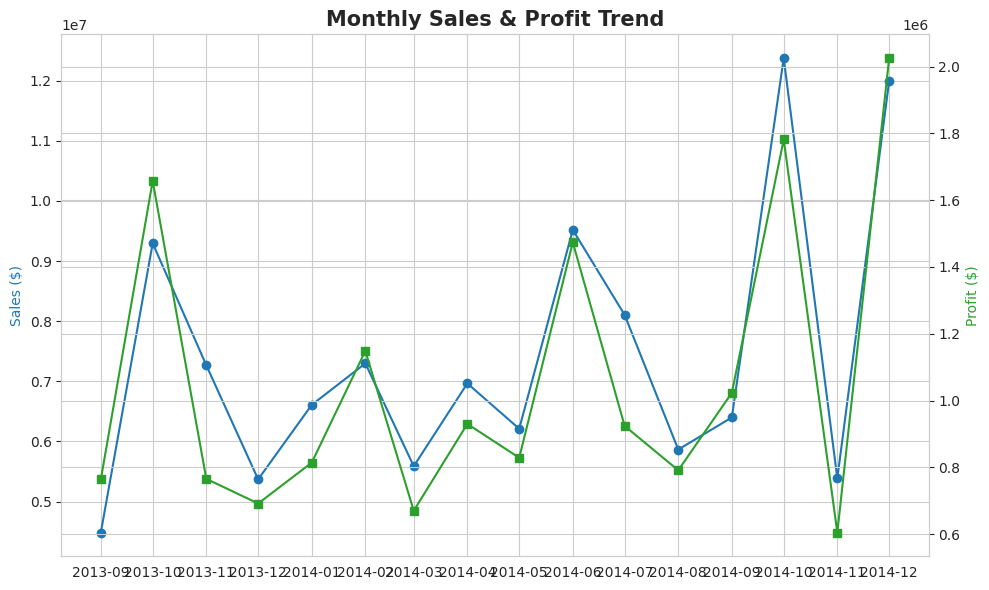

In [19]:
monthly_ts = df.set_index("Date").resample("MS")[["Sales", "Profit"]].sum()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(monthly_ts.index, monthly_ts["Sales"], marker="o", color="tab:blue", label="Sales")
ax2.plot(monthly_ts.index, monthly_ts["Profit"], marker="s", color="tab:green", label="Profit")
ax1.set_ylabel("Sales ($)", color="tab:blue")
ax2.set_ylabel("Profit ($)", color="tab:green")
ax1.set_title("Monthly Sales & Profit Trend", fontsize=15, fontweight="bold")
plt.xticks(monthly_ts.index, [d.strftime("%Y-%m") for d in monthly_ts.index], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("charts/06_monthly_trend.png", dpi=150)
plt.show()

## 4. Key Findings

- **Enterprise is the only segment operating at a net loss** (-3.13% margin, -\$614,546 total), concentrated in Medium/High discount orders (33 of 58 loss-making orders are in the High band).
- **Channel Partners delivers the best margin in the business** (73.1%) despite the smallest revenue base.
- **Margin declines near-linearly with discount depth**: 21.9% (None) → 17.9% (Low) → 14.4% (Medium) → 9.1% (High).
- **Paseo drives the most revenue** (\$33.0M); **Amarilla is the most margin-efficient product** (15.9%).
- **All five countries are solidly profitable** (12–16% margin) — geography is not a risk factor.
- **October and December are consistently the strongest revenue months** across both years covered.

## 5. Recommendations

1. **Cap Enterprise discounting** — restructure or cap High-band discounts for Enterprise accounts, since this single combination accounts for the business's only losses.
2. **Investigate why Enterprise needs deep discounts** (competitive pressure, long sales cycles) and address it with bundling or value-based offers instead of pure price cuts.
3. **Scale the Channel Partners motion** — its 73% margin suggests a highly efficient go-to-market worth investing in further.
4. **Use Amarilla and VTT as margin anchors** in bundles and upsell offers.
5. **Align seasonal planning with the October–December peaks** for inventory, staffing, and marketing spend.

In [20]:
conn.close()
print("Pipeline complete. Cleaned data, SQLite DB, and 6 charts saved to disk.")

Pipeline complete. Cleaned data, SQLite DB, and 6 charts saved to disk.
